## Hw 1

### Part 2 
Using a modified **10-armed Bandit** in this exercise to demonstrate the limitations of sample-average methods when dealing with nonstationary problems. In the part2, we will focus on the **Constant step-size method** (CS). In part1, we find that constant step-size method performed better than **Sample-average method**  on nonstationary problem. However, does the action selection method also affect the performance? Therefore, in Part 2, we will explore under the same constant step size whether the action selection strategy also influences performance.

##### 10-armed bandit:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random, math

np.random.seed(1)

class ten_armed_bandit:
    def __init__(self, k=10, walks=0.01):
        self.arms = k
        self.walks = 0.01
        self.q_t = np.zeros(k)

    def reward(self, arm):
        return np.random.normal(self.q_t[arm], 1)

    def update_q_t(self):
        self.q_t += np.random.normal(0, self.walks, self.arms)

    def find_best_arm(self):
        return np.argmax(self.q_t)


In [2]:
def run(k_arms=10,walks = 0.01, num_steps=10000, num_exp = 2000, ep=0.1, a_val = 0.1, method="egreedy"):
    avg_rewards = np.zeros(num_steps)
    opt_arms = np.zeros(num_steps)

    for exp in range(num_exp):
        if exp % 100 == 0:
            print(f"Experiment {exp}/{num_exp} ...")

        bandit = ten_armed_bandit(k=k_arms, walks=walks)

        est_Q = np.zeros(bandit.arms) #Q values for each arm
        arm_counts = np.zeros(bandit.arms)

        for step in range(num_steps):
            if method == "egreedy": #base line ep=0.1 
                if np.random.rand() < ep:
                    arm = np.random.randint(bandit.arms)
                else:
                    arm = np.argmax(est_Q)

            elif method == "UCB": # confidence parameter c = 2
                arm = np.argmax(est_Q + 2*np.sqrt(np.log(step+1)/(arm_counts+1e-5)))
            
            elif method == "softmax": # Temperature = 1
                probs = np.exp(est_Q/1.0) / np.sum(np.exp(est_Q/1.0))
                arm = np.random.choice(bandit.arms, p=probs)    
            
            else:
                raise ValueError("Unknown method")

            #reward
            reward = bandit.reward(arm) 
            
            bandit.update_q_t()
            opt_arm = bandit.find_best_arm()

            #update
            est_Q[arm] += a_val*(reward - est_Q[arm])
            arm_counts[arm] += 1

            #results
            avg_rewards[step] += reward
            if arm == opt_arm:
                opt_arms[step] += 1

    avg_rewards /= num_exp
    opt_arms = (opt_arms / num_exp) * 100

    return avg_rewards, opt_arms

    


##### Constants

Defined some constant that will be used in the agent and update the reward

In [3]:
num_arms = 10  
num_steps = 10000  
num_exp = 2000  
epsilon = 0.1  
alpha = 0.1 
random_walks = 0.01 

##### Experiment: epsilon-greedy, ucb, softmax

Experiment 0/2000 ...
Experiment 100/2000 ...
Experiment 200/2000 ...
Experiment 300/2000 ...
Experiment 400/2000 ...
Experiment 500/2000 ...
Experiment 600/2000 ...
Experiment 700/2000 ...
Experiment 800/2000 ...
Experiment 900/2000 ...
Experiment 1000/2000 ...
Experiment 1100/2000 ...
Experiment 1200/2000 ...
Experiment 1300/2000 ...
Experiment 1400/2000 ...
Experiment 1500/2000 ...
Experiment 1600/2000 ...
Experiment 1700/2000 ...
Experiment 1800/2000 ...
Experiment 1900/2000 ...
Experiment 0/2000 ...
Experiment 100/2000 ...
Experiment 200/2000 ...
Experiment 300/2000 ...
Experiment 400/2000 ...
Experiment 500/2000 ...
Experiment 600/2000 ...
Experiment 700/2000 ...
Experiment 800/2000 ...
Experiment 900/2000 ...
Experiment 1000/2000 ...
Experiment 1100/2000 ...
Experiment 1200/2000 ...
Experiment 1300/2000 ...
Experiment 1400/2000 ...
Experiment 1500/2000 ...
Experiment 1600/2000 ...
Experiment 1700/2000 ...
Experiment 1800/2000 ...
Experiment 1900/2000 ...
Experiment 0/2000 ...
Ex

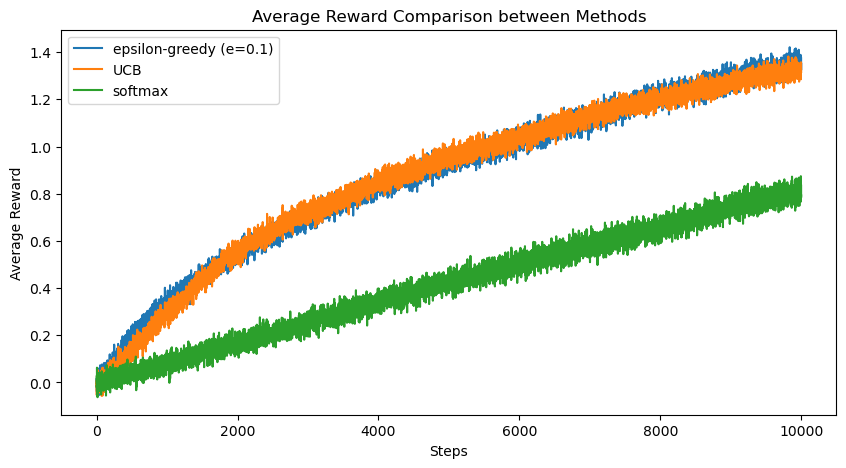

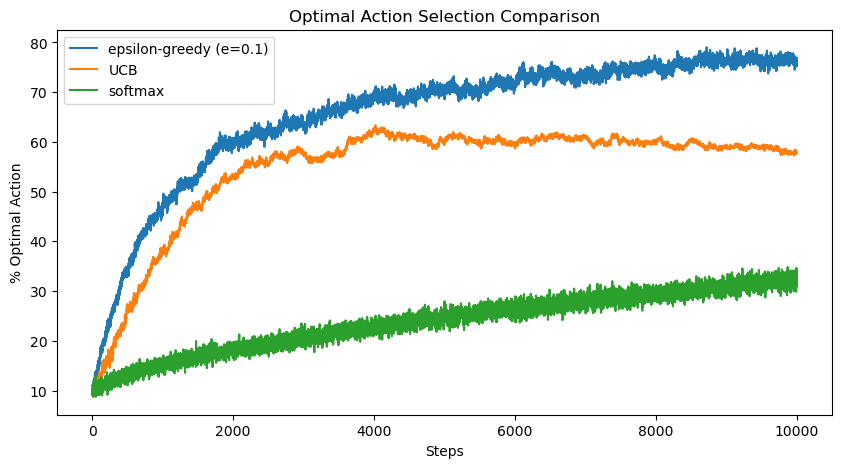

In [4]:

avg_rewards1, opt_arms1 = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha, method="egreedy")
avg_rewards2, opt_arms2 = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha, method="UCB")
avg_rewards3, opt_arms3 = run(num_arms, random_walks, num_steps, num_exp, epsilon, alpha, method="softmax")

plt.figure(figsize=(10, 5))
plt.plot(avg_rewards1, label="epsilon-greedy (e=0.1)")
plt.plot(avg_rewards2, label="UCB")
plt.plot(avg_rewards3, label="softmax")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward Comparison between Methods")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(opt_arms1, label="epsilon-greedy (e=0.1)")
plt.plot(opt_arms2, label="UCB")
plt.plot(opt_arms3, label="softmax")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Selection Comparison")
plt.legend()
plt.show()